In [ ]:
!git clone https://github.com/denisevaldivia/Disney_GAN.git
%cd Disney_GAN

Cloning into 'Disney_GAN'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 114 (delta 1), reused 5 (delta 1), pack-reused 105 (from 1)
Receiving objects: 100% (114/114), 161.15 MiB | 18.47 MiB/s, done.
Resolving deltas: 100% (42/42), done.
Updating files: 100% (28/28), done.
/content/Disney_GAN


In [ ]:
import sys
import os
import torch
import numpy as np
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from pytorch_fid import fid_score
from pytorch_fid.inception import InceptionV3

sys.path.insert(0, '/content/Disney_GAN/src/utils')
sys.path.append("/content/Disney_GAN/src/utils")
from networks import define_G

In [ ]:
def load_generator(checkpoint_path, device):
    netG = define_G(1, 3, 64, 'unet_256', 'batch',
                    use_dropout=False,  # eval mode, no dropout
                    init_type='normal', init_gain=0.02, gpu_ids=[])
    ckpt = torch.load(checkpoint_path, map_location='cpu')
    state_dict = ckpt['G'] if isinstance(ckpt, dict) and 'G' in ckpt else ckpt
    netG.load_state_dict(state_dict, strict=True)
    netG.to(device)
    netG.eval()
    print(f"Model loaded: {os.path.basename(checkpoint_path)}")
    return netG

In [ ]:
def preprocess_sketch(img_path):
    """Accepts a sketch-only image"""
    img = Image.open(img_path).convert('RGB')
    img = img.resize((256, 256), Image.BICUBIC)

    tensor = transforms.ToTensor()(img)
    tensor = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))(tensor)

    # RGB to gray after normalize
    gray = tensor[0] * 0.299 + tensor[1] * 0.587 + tensor[2] * 0.114
    return gray.unsqueeze(0)  # (1, 256, 256)

In [ ]:
def generate(netG, sketch_path, device, save_path=None):
    A = preprocess_sketch(sketch_path).unsqueeze(0).to(device)

    with torch.no_grad():
        fake_B = netG(A)

    out = fake_B.squeeze(0).cpu()
    out = (out * 0.5 + 0.5).clamp(0, 1)
    out_np = (out.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    result = Image.fromarray(out_np)

    if save_path:
        result.save(save_path)

    return result

In [ ]:
def generate_and_plot(netG, folder_path, device, save_path="/content/generations.png", cols_per_row=5):

    extensions = {'.png', '.jpg', '.jpeg', '.webp', '.bmp'}
    sketch_paths = sorted([
        os.path.join(folder_path, f) for f in os.listdir(folder_path)
        if os.path.splitext(f)[1].lower() in extensions
    ])

    if not sketch_paths:
        print(f"No images found in {folder_path}")
        return
    print(f"Found {len(sketch_paths)} images")

    n = len(sketch_paths)
    n_cols = min(n, cols_per_row)
    n_rows = ((n - 1) // cols_per_row + 1) * 2  # x2  sketch + generated

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(n_rows, n_cols)

    for idx, path in enumerate(sketch_paths):
        col = idx % cols_per_row
        sketch_row = (idx // cols_per_row) * 2      # sketch
        gen_row    = sketch_row + 1                  # generado

        # Input sketch
        sketch = Image.open(path).convert('RGB').resize((256, 256), Image.BICUBIC)
        axes[sketch_row, col].imshow(np.array(sketch), cmap='gray')
        axes[sketch_row, col].set_title(os.path.basename(path), fontsize=8)
        axes[sketch_row, col].axis('off')

        # Generated
        result = generate(netG, path, device)
        axes[gen_row, col].imshow(np.array(result))
        axes[gen_row, col].axis('off')

    # Labels por cada par de filas
    for block in range(n_rows // 2):
        axes[block * 2,     0].set_ylabel('Sketch',    fontsize=10, rotation=0, labelpad=60, va='center')
        axes[block * 2 + 1, 0].set_ylabel('Generated', fontsize=10, rotation=0, labelpad=60, va='center')

    # Ocultar ejes vacíos
    for idx in range(n, (n_rows // 2) * cols_per_row):
        col = idx % cols_per_row
        sketch_row = (idx // cols_per_row) * 2
        axes[sketch_row,     col].axis('off')
        axes[sketch_row + 1, col].axis('off')

    plt.suptitle('Sketch → Disney', fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

In [ ]:
import zipfile

with zipfile.ZipFile("/content/test.zip", 'r') as z:
    z.extractall("/content/test")

print("Done!")

Done!


initialize network with normal
Model loaded: 200_net_gen.pt
Found 27 images


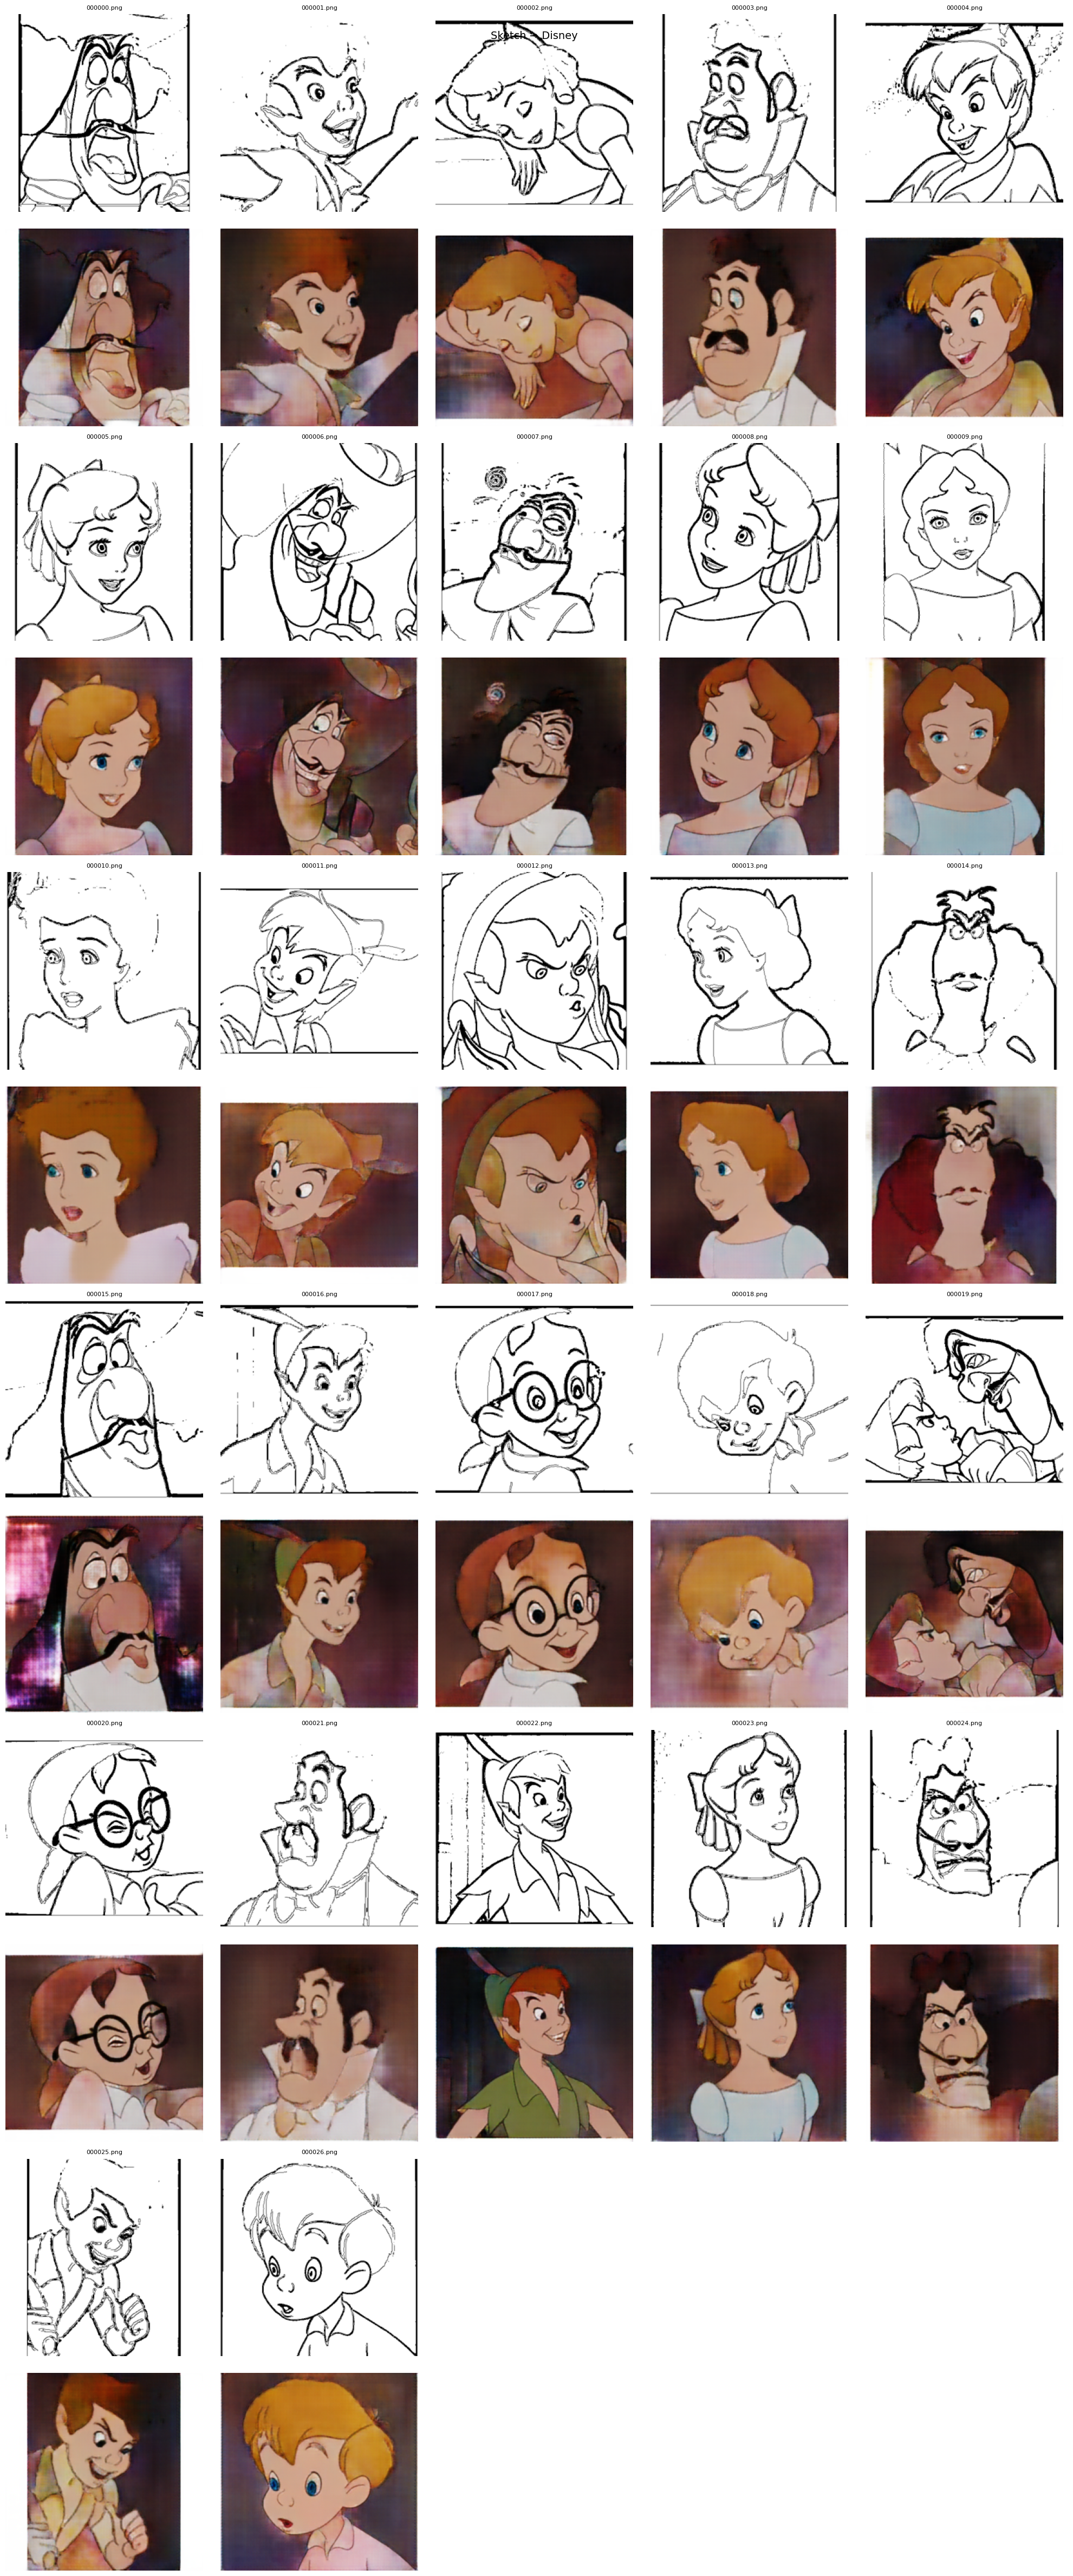

Saved: /content/generations.png


In [ ]:
# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
netG = load_generator(checkpoint_path="/content/Disney_GAN/src/Weights/200_net_gen.pt",device=device)
generate_and_plot(netG=netG,folder_path="/content/test",device=device,save_path="/content/generations.png")

In [ ]:
def calculate_fid(real_path, generated_path, device='cuda', img_size=256):
    # Resize todas las imágenes al mismo tamaño antes de calcular
    from torchvision import transforms
    from torch.utils.data import DataLoader, Dataset
    from PIL import Image
    import os
    import numpy as np

    transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),  # → [0, 1], eso es suficiente para Inception
])

    class ImageFolder(Dataset):
        def __init__(self, folder):
            exts = {'.png', '.jpg', '.jpeg'}
            self.paths = [os.path.join(folder, f) for f in os.listdir(folder)
                         if os.path.splitext(f)[1].lower() in exts]
        def __len__(self): return len(self.paths)
        def __getitem__(self, i):
            return transform(Image.open(self.paths[i]).convert('RGB'))

    dims = 2048
    block_idx = InceptionV3.BLOCK_INDEX_BY_DIM[dims]
    model = InceptionV3([block_idx]).to(device)
    model.eval()

    def get_stats(folder):
        loader = DataLoader(ImageFolder(folder), batch_size=8,
                           num_workers=0, shuffle=False)
        acts = []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                pred = model(batch)[0].squeeze(-1).squeeze(-1)
                acts.append(pred.cpu().numpy())
        acts = np.concatenate(acts, axis=0)
        mu = np.mean(acts, axis=0)
        sigma = np.cov(acts, rowvar=False)
        return mu, sigma

    print("Computing stats for real images...")
    m1, s1 = get_stats(real_path)
    print("Computing stats for generated images...")
    m2, s2 = get_stats(generated_path)

    fid = fid_score.calculate_frechet_distance(m1, s1, m2, s2)
    print(f"\nFID: {fid:.4f}")
    return fid


fid = calculate_fid(
    real_path="/content/Test/Real",
    generated_path="/content/Test/Generated",
    device="cpu"
)

Computing stats for real images...
Computing stats for generated images...

FID: 150.3722


In [ ]:
def calculate_ssim(real_folder, generated_folder):
    real_images = sorted([f for f in os.listdir(real_folder) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    gen_images  = sorted([f for f in os.listdir(generated_folder) if f.lower().endswith(('.png','.jpg','.jpeg'))])

    scores = []

    for real_name, gen_name in zip(real_images, gen_images):
        real_path = os.path.join(real_folder, real_name)
        gen_path  = os.path.join(generated_folder, gen_name)

        real_img = Image.open(real_path).convert('L')  # grayscale
        gen_img  = Image.open(gen_path).convert('L')

        real_np = np.array(real_img)
        gen_np  = np.array(gen_img)

        score = ssim(real_np, gen_np)
        scores.append(score)

    return np.mean(scores)

ssim_score = calculate_ssim("/content/Test/Real", "/content/Test/Generated")
print(f"SSIM Mean: {ssim_score:.4f}")

SSIM Mean: 0.3645
